In [15]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

%matplotlib inline

In [25]:
DATA_ROOT = "../data/raw/hyper-kvasir-labeled-image"

LABELS_CSV = os.path.join(DATA_ROOT, "image-labels.csv")
LOWER_GI = os.path.join(DATA_ROOT, "lower-gi-tract")
UPPER_GI = os.path.join(DATA_ROOT, "upper-gi-tract")

print("DATA_ROOT:", DATA_ROOT)
print("LOWER_GI exists:", os.path.exists(LOWER_GI))
print("UPPER_GI exists:", os.path.exists(UPPER_GI))
print("LABELS CSV exists:", os.path.exists(LABELS_CSV))

DATA_ROOT: ../data/raw/hyper-kvasir-labeled-image
LOWER_GI exists: True
UPPER_GI exists: True
LABELS CSV exists: True


In [26]:
labels_df = pd.read_csv(LABELS_CSV)
labels_df.head()

,Video file,Organ,Finding,Classification
0,000e3fee-7f5c-4819-9f9c-4c983b68888a,Lower GI,cecum,anatomical-landmarks
1,001a41c2-2a5d-40b1-8fd5-b5f2f292277b,Lower GI,cecum,anatomical-landmarks
2,006af0aa-2044-4477-964d-10d9e043fb78,Lower GI,cecum,anatomical-landmarks
3,00832522-ab8e-4b98-bfce-93a777929571,Lower GI,cecum,anatomical-landmarks
4,012ab888-64e6-4361-9745-f52b4a03ba75,Lower GI,cecum,anatomical-landmarks


In [29]:
print("Total samples:", len(labels_df))
print("\nColumns:")
print(labels_df.columns)

print("\nUnique organs:")
print(labels_df["Organ"].value_counts())

print("\nUnique findings:")
print(labels_df["Finding"].value_counts().head())

Total samples: 10662

Columns:
Index(['Video file', 'Organ', 'Finding', 'Classification'], dtype='object')

Unique organs:
Organ
Lower GI    7210
Upper GI    3452
Name: count, dtype: int64

Unique findings:
Finding
bbps-2-3              1148
polyps                1028
cecum                 1009
dyed-lifted-polyps    1002
pylorus                999
Name: count, dtype: int64


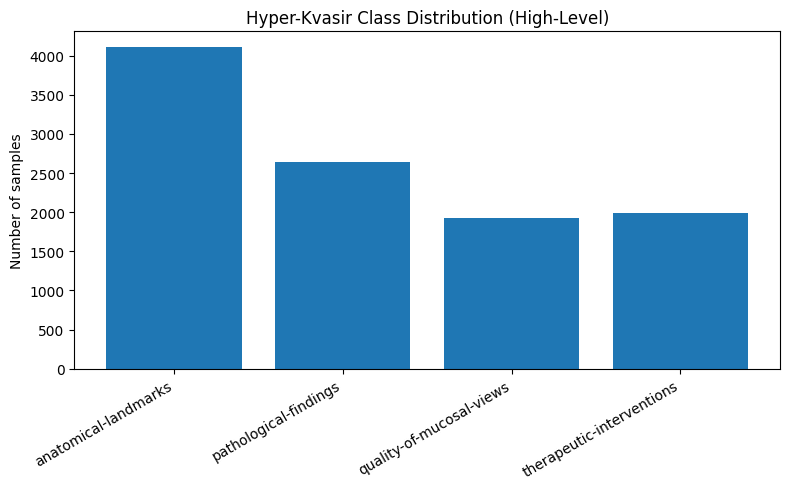

In [31]:
class_counts = Counter(labels_df["Classification"])

plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of samples")
plt.title("Hyper-Kvasir Class Distribution (High-Level)")
plt.tight_layout()
plt.show()

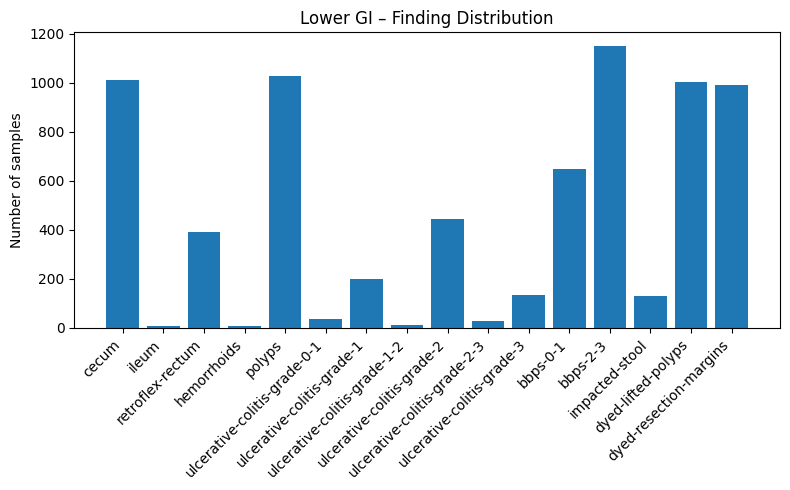

In [ ]:
lower_gi_df = labels_df[labels_df["Organ"] == "Lower GI"]

organ_counts = Counter(lower_gi_df["Finding"])
labels_df["Finding"]
plt.figure(figsize=(8,5))
plt.bar(organ_counts.keys(), organ_counts.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of samples")
plt.title("Lower GI – Finding Distribution")
plt.tight_layout()
plt.show()

In [33]:
count = 0
for root, _, files in os.walk(LOWER_GI):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            count += 1

print("Total Lower GI images found:", count)

Total Lower GI images found: 7210


In [34]:
def show_sample_images(folder, n=4, seed=42):
    """
    Display random sample images from a dataset folder (recursive).
    Used for qualitative dataset validation.
    """
    image_paths = []

    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(os.path.join(root, f))

    if not image_paths:
        print(f"No images found in: {folder}")
        return

    random.seed(seed)
    sample_images = random.sample(image_paths, min(n, len(image_paths)))

    plt.figure(figsize=(3*n, 3))
    for i, img_path in enumerate(sample_images):
        img = Image.open(img_path).convert("RGB")
        class_name = os.path.basename(os.path.dirname(img_path))

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(class_name, fontsize=9)
        plt.axis("off")

    plt.suptitle("Random Hyper-Kvasir Samples (Lower GI)", fontsize=12)
    plt.tight_layout()
    plt.show()

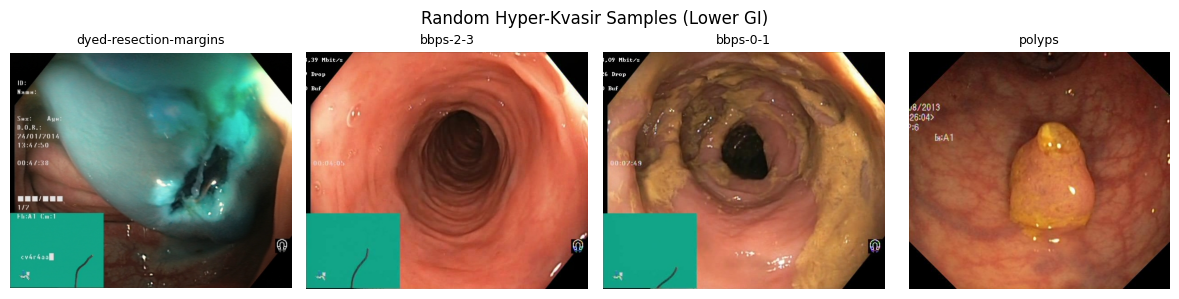

In [36]:
show_sample_images(LOWER_GI, n=4)

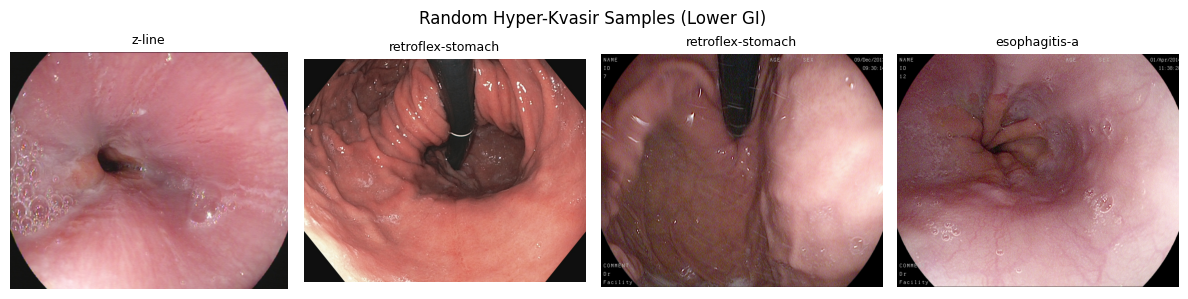

In [37]:
show_sample_images(UPPER_GI, n=4)

In [23]:
import os

count = 0
for root, _, files in os.walk(LOWER_GI):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            count += 1

print("Total images found:", count)

Total images found: 7210


In [24]:
def show_sample_images(folder, n=4, seed=42):
    """
    Display random sample images from a dataset folder (recursive).
    Used for qualitative dataset validation.
    """
    image_paths = []

    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(os.path.join(root, f))

    if not image_paths:
        print(f"No images found in: {folder}")
        return

    random.seed(seed)
    sample_images = random.sample(image_paths, min(n, len(image_paths)))

    plt.figure(figsize=(3 * n, 3))
    for i, img_path in enumerate(sample_images):
        img = Image.open(img_path).convert("RGB")

        # Folder name = class label
        class_name = os.path.basename(os.path.dirname(img_path))

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(class_name, fontsize=9)
        plt.axis("off")

    plt.suptitle("Random Hyper-Kvasir Samples (Lower GI)", fontsize=12)
    plt.tight_layout()
    plt.show()